# TP3 - Carga y Descarga de un Capacitor

**Materia:** Electricidad y Magnetismo

**Integrantes:**
* Fernanda Perez
* Tomas Aragusuku
* Jonathan Gomez
* Carla Rocca

## Objetivo
Antes de la instancia de medición, la cátedra nos pidió una **muestra teórica** del comportamiento de carga y descarga de un capacitor de $C = 2\mu F$ en serie con una resistencia de $R = 150\Omega$.

El objetivo de este notebook es:
1. Calcular la constante de tiempo $\tau = R.C$ del circuito.
2. Graficar la tensión $V_C(t)$ y la corriente $I(t)$ esperadas durante $5\tau$ de carga y $5\tau$ de descarga (es decir, un período $T = 10\tau$), repitiendo el ciclo para verificar la periodicidad.
3. Usar estos resultados teóricos para elegir la frecuencia del generador de funciones y la escala de tiempo del osciloscopio en la instancia de medición real, y como referencia para comparar contra los datos experimentales medidos con el osciloscopio (última sección).

## Introducción teórica

Un capacitor conectado en serie con una resistencia forma un circuito **RC**. Si se lo alimenta con una tensión $V_0$ (por ejemplo, la salida de un generador de funciones en modo onda cuadrada), el capacitor se **carga** mientras la fuente está conectada y se **descarga** a través de la resistencia cuando la fuente se cortocircuita o se desconecta.

**Carga:**
$$V_C(t) = V_0\left(1 - e^{-t/\tau}\right) \qquad I(t) = \frac{V_0}{R}\,e^{-t/\tau}$$

**Descarga:**
$$V_C(t) = V_0\,e^{-t/\tau} \qquad I(t) = -\frac{V_0}{R}\,e^{-t/\tau}$$

donde $\tau = R.C$ es la **constante de tiempo** del circuito. El signo negativo en la corriente de descarga indica que circula en sentido opuesto al de la carga, aunque su módulo responde a la misma exponencial.

Una propiedad útil de la exponencial es que en $t = 5\tau$ el capacitor ya alcanzó más del **99,3%** de su valor final ($1 - e^{-5} \approx 0,993$). Por eso, si se arma una señal cuadrada de período $T = 10\tau$ (5$\tau$ de nivel alto + 5$\tau$ de nivel bajo), el capacitor alcanza a completar prácticamente toda la carga y toda la descarga dentro de cada semiperíodo, y el patrón se repite de forma periódica en el osciloscopio.

## Elección de los parámetros

$R = 150\,\Omega$ y $C = 2\,\mu F$ son los valores del circuito. La tensión $V_0$ quedaba a elección del grupo; elegimos **$V_0 = 5V$** porque:

* Es un valor estándar de fuente/generador de laboratorio, fácil de fijar con precisión.
* Da una corriente inicial de carga y una tensión final cómodas de leer tanto en el osciloscopio como en el multímetro.
* Conviene revisar la potencia que va a disipar la resistencia en el peor caso (capacitor descargado, $t=0$), para elegir una $R$ de potencia nominal adecuada. Esto se calcula en la siguiente celda.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Parámetros del circuito (R y C del circuito, V0 elegido por el grupo)
R = 150        # Resistencia [ohm]
C = 2e-6       # Capacidad [F]
V0 = 5         # Tensión de la fuente [V]

tau = R * C            # Constante de tiempo RC
t_fase = 5 * tau       # Duración de cada fase (carga o descarga) -> ~99.3% del valor final
T = 2 * t_fase         # Período completo de un ciclo carga+descarga (= 10*tau)

print(f"tau        = {tau*1e3:.3f} ms")
print(f"5*tau      = {t_fase*1e3:.3f} ms")
print(f"T = 10*tau = {T*1e3:.3f} ms")
print(f"f = 1/T    = {1/T:.1f} Hz  (frecuencia sugerida para el generador de funciones)")


tau        = 0.300 ms
5*tau      = 1.500 ms
T = 10*tau = 3.000 ms
f = 1/T    = 333.3 Hz  (frecuencia sugerida para el generador de funciones)


In [3]:
# Corriente y potencia en el instante más exigente (t=0 de la carga, capacitor descargado)
I0 = V0 / R
P0 = V0**2 / R

print(f"I0 (t=0, carga) = {I0*1e3:.2f} mA")
print(f"P0 (t=0, carga) = {P0*1e3:.1f} mW")


I0 (t=0, carga) = 33.33 mA
P0 (t=0, carga) = 166.7 mW


Con $V_0 = 5V$, la corriente inicial es de aproximadamente **33,3 mA** y la potencia disipada en la resistencia en ese instante es de **~167 mW**. Una resistencia común de $1/4W$ (250 mW) alcanza, aunque trabajaría al ~67% de su potencia nominal; para tener más margen conviene usar una $R$ de $150\Omega$ de $1/2W$.

## Construcción de las curvas teóricas

Armamos las curvas de $V_C(t)$ e $I(t)$ concatenando fases de carga y descarga de duración $5\tau$ cada una, repitiendo el ciclo dos veces para verificar la periodicidad.

In [4]:
n_ciclos = 2     # cantidad de ciclos carga+descarga a graficar
n_puntos = 300   # puntos por fase (resolución de la curva)

t_list, v_list, i_list = [], [], []
t_acumulado = 0.0

for ciclo in range(n_ciclos):
    # --- Fase de carga ---
    t = np.linspace(0, t_fase, n_puntos)
    v = V0 * (1 - np.exp(-t / tau))
    i = (V0 / R) * np.exp(-t / tau)

    t_list.append(t + t_acumulado)
    v_list.append(v)
    i_list.append(i)
    t_acumulado += t_fase

    # --- Fase de descarga ---
    t = np.linspace(0, t_fase, n_puntos)
    v = V0 * np.exp(-t / tau)
    i = -(V0 / R) * np.exp(-t / tau)   # mismo módulo, sentido opuesto a la carga

    t_list.append(t + t_acumulado)
    v_list.append(v)
    i_list.append(i)
    t_acumulado += t_fase

t_total = np.concatenate(t_list)
v_total = np.concatenate(v_list)
i_total = np.concatenate(i_list)


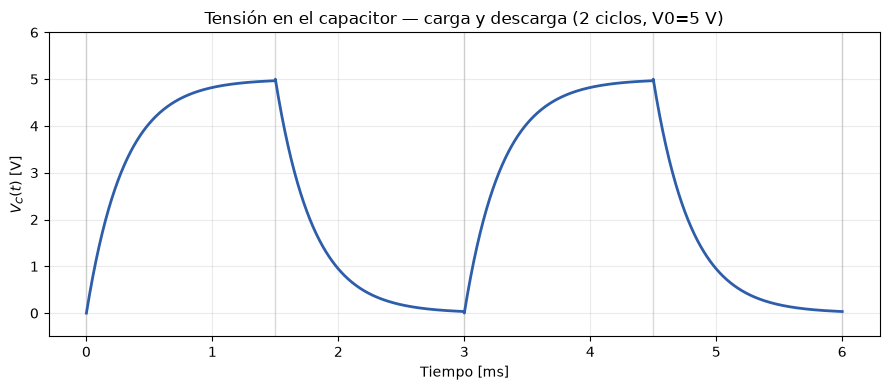

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_total * 1e3, v_total, color="#2E5EAA", linewidth=2)

for k in range(2 * n_ciclos + 1):
    ax.axvline(k * t_fase * 1e3, color="0.85", linewidth=1, zorder=0)

ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel(r"$V_C(t)$ [V]")
ax.set_title(f"Tensión en el capacitor \u2014 carga y descarga ({n_ciclos} ciclos, V0={V0} V)")
ax.grid(alpha=0.25)
ax.set_ylim(-0.5, V0 + 1)
fig.tight_layout()
plt.show()


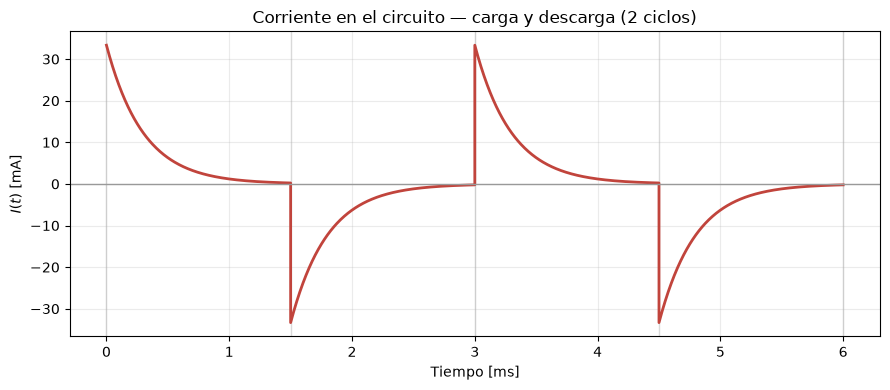

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_total * 1e3, i_total * 1e3, color="#C1443C", linewidth=2)
ax.axhline(0, color="0.6", linewidth=1)

for k in range(2 * n_ciclos + 1):
    ax.axvline(k * t_fase * 1e3, color="0.85", linewidth=1, zorder=0)

ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel(r"$I(t)$ [mA]")
ax.set_title(f"Corriente en el circuito \u2014 carga y descarga ({n_ciclos} ciclos)")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Análisis

* En cada tramo de $5\tau$ la tensión $V_C(t)$ llega prácticamente a $V_0$ (carga) o a $0V$ (descarga), lo que confirma que un período $T = 10\tau$ alcanza para observar el ciclo completo sin cortarlo.
* La corriente $I(t)$ tiene la misma forma exponencial en ambas fases, pero cambia de signo entre carga y descarga porque el sentido de circulación se invierte.
* Con $\tau \approx 0,30\,ms$, el fenómeno completo dura unos pocos milisegundos: **no se puede seguir a ojo con un cronómetro**, por lo que la medición real va a requerir un generador de funciones en $\approx 333\,Hz$ (onda cuadrada) y un osciloscopio con una base de tiempo de pocos $ms/div$.

## Mediciones con el osciloscopio

Con el circuito armado se capturó la tensión en el capacitor con un osciloscopio. El archivo `DS0000.CSV` tiene la configuración de la captura (encabezado) y 4000 muestras crudas, en cuentas del conversor A/D. Se convierten a volts con la escala vertical del encabezado (25 cuentas por división) y el tiempo se arma con el período de muestreo.

In [7]:
# Lectura del CSV del osciloscopio: encabezado + datos crudos
with open("DS0000.CSV") as f:
    lineas = f.read().splitlines()

encabezado = {}
for k, linea in enumerate(lineas):
    campos = linea.split(",")
    if campos[0] == "Waveform Data":
        i_datos = k + 1
        break
    encabezado[campos[0]] = campos[1]

raw = np.array([float(l.split(",")[0]) for l in lineas[i_datos:] if l.strip()])
v_div = float(encabezado["Vertical Scale"])   # [V/div]
dt = float(encabezado["Sampling Period"])     # [s]

t_med = np.arange(len(raw)) * dt
v_med = raw * v_div / 25                      # 25 cuentas por división vertical

# Niveles alto y bajo de la señal (mediana de los extremos, para no depender del ruido)
v_alto = np.median(v_med[v_med > np.percentile(v_med, 90)])
v_bajo = np.median(v_med[v_med < np.percentile(v_med, 10)])

print(f"Muestras: {len(raw)}  |  período de muestreo: {dt*1e6:.0f} us  |  duración: {t_med[-1]*1e3:.1f} ms")
print(f"Nivel alto  = {v_alto:.2f} V")
print(f"Nivel bajo  = {v_bajo:.2f} V")
print(f"Excursión   = {v_alto - v_bajo:.2f} V pico a pico")

Muestras: 4000  |  período de muestreo: 4 us  |  duración: 16.0 ms
Nivel alto  = 1.32 V
Nivel bajo  = -1.26 V
Excursión   = 2.58 V pico a pico


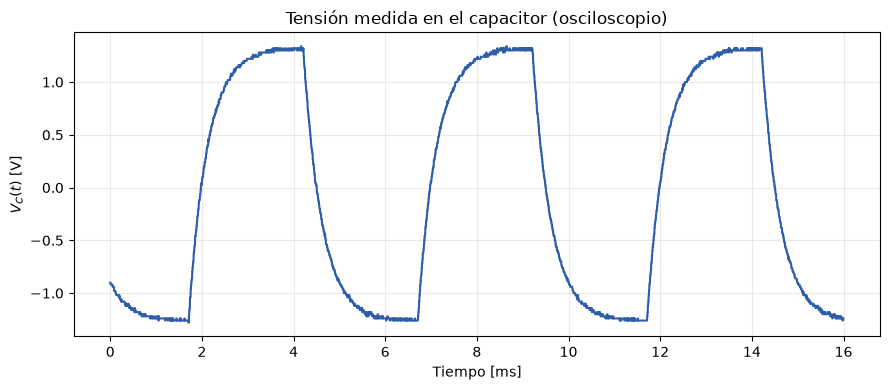

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_med * 1e3, v_med, color="#2E5EAA", linewidth=1.5)
ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel(r"$V_C(t)$ [V]")
ax.set_title("Tensión medida en el capacitor (osciloscopio)")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Constante de tiempo medida

Como $V_C(t)$ es una exponencial, se puede sacar $\tau$ de la parte de cada flanco que va hacia su valor final. Con $y$ la señal normalizada entre el nivel bajo (0) y el alto (1), lo que **falta** para llegar al valor final es $e^{-t/\tau}$ en cada flanco (en la carga $1-y$, en la descarga $y$). Entonces $\ln(\text{falta})$ es una recta en $t$ de pendiente $-1/\tau$, y se ajusta por cuadrados mínimos con `np.polyfit`.

In [9]:
y = (v_med - v_bajo) / (v_alto - v_bajo)      # 0 = nivel bajo, 1 = nivel alto

# Cruces por la mitad de la señal (0,5): hacia arriba = flanco de carga, hacia abajo = descarga
cruce_sube = np.where((y[:-1] < 0.5) & (y[1:] >= 0.5))[0]
cruce_baja = np.where((y[:-1] > 0.5) & (y[1:] <= 0.5))[0]

# El ruido genera cruces repetidos (incluso de signo contrario) sobre un mismo flanco:
# nos quedamos con el primero de cada grupo, separando los flancos reales por al menos 1 ms
flancos = []
for i, es_carga in sorted([(i, True) for i in cruce_sube] + [(i, False) for i in cruce_baja]):
    if not flancos or i - flancos[-1][0] > int(1e-3 / dt):
        flancos.append((i, es_carga))

def ajustar_tau(i, es_carga, ventana=1.6e-3):
    a = i - int(0.2e-3 / dt)
    b = min(i + int(ventana / dt), len(y))
    falta = (1 - y[a:b]) if es_carga else y[a:b]
    ok = (falta > 0.03) & (falta < 0.95)       # fuera del piso de ruido y del tramo plano previo
    pend, ordenada = np.polyfit(t_med[a:b][ok], np.log(falta[ok]), 1)
    return -1 / pend, -ordenada / pend         # tau y el instante t0 en que empieza el flanco

taus_carga, taus_descarga = [], []
for i, es_carga in flancos:
    tau_i, t0_i = ajustar_tau(i, es_carga)
    (taus_carga if es_carga else taus_descarga).append(tau_i)
    print(f"{'Carga   ' if es_carga else 'Descarga'} en t = {t0_i*1e3:6.2f} ms  ->  tau = {tau_i*1e3:.3f} ms")

tau_med = np.mean(taus_carga + taus_descarga)
tau_std = np.std(taus_carga + taus_descarga, ddof=1)
tau_teo = R * C
print(f"\ntau medido  = {tau_med*1e3:.3f} ms  (+/- {tau_std*1e3:.3f} ms, dispersión entre flancos)")
print(f"tau teórico = {tau_teo*1e3:.3f} ms  (R*C con R = {R} ohm)")
print(f"Diferencia  = {(tau_med - tau_teo) / tau_teo * 100:+.0f} %")

Carga    en t =   1.70 ms  ->  tau = 0.412 ms
Descarga en t =   4.22 ms  ->  tau = 0.397 ms
Carga    en t =   6.71 ms  ->  tau = 0.408 ms
Descarga en t =   9.22 ms  ->  tau = 0.396 ms
Carga    en t =  11.70 ms  ->  tau = 0.411 ms
Descarga en t =  14.21 ms  ->  tau = 0.398 ms

tau medido  = 0.404 ms  (+/- 0.008 ms, dispersión entre flancos)
tau teórico = 0.300 ms  (R*C con R = 150 ohm)
Diferencia  = +35 %


### Comparación con la curva teórica

Se superpone un flanco de carga y uno de descarga medidos con la exponencial teórica ($\tau = RC$) y con la exponencial de $\tau$ medido, ambas escaladas a los niveles alto y bajo de la señal real y con el mismo instante de inicio del flanco.

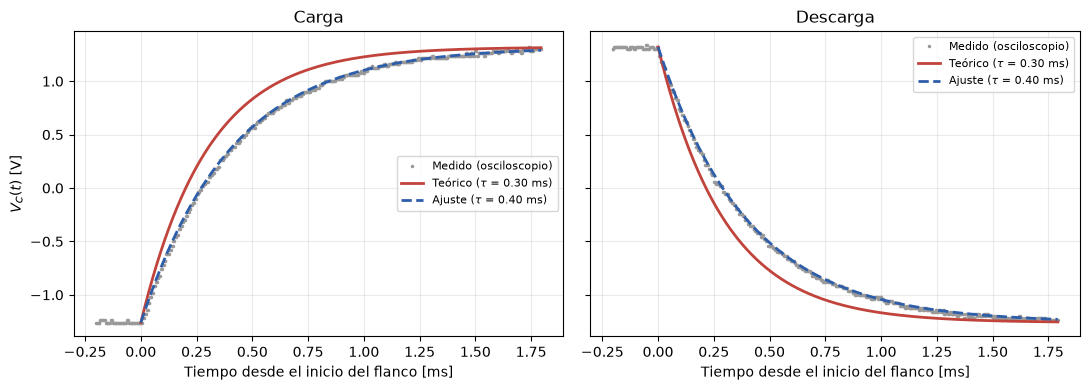

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, (i, es_carga), titulo in zip(axs, [[f for f in flancos if f[1]][1], [f for f in flancos if not f[1]][0]], ["Carga", "Descarga"]):
    _, t0 = ajustar_tau(i, es_carga)
    a = int((t0 - 0.2e-3) / dt)
    b = int((t0 + 1.8e-3) / dt)
    tt = t_med[a:b] - t0
    tp = np.linspace(0, tt[-1], 400)
    if es_carga:
        f = lambda x, tau: v_bajo + (v_alto - v_bajo) * (1 - np.exp(-x / tau))
    else:
        f = lambda x, tau: v_bajo + (v_alto - v_bajo) * np.exp(-x / tau)

    ax.plot(tt * 1e3, v_med[a:b], ".", color="0.6", markersize=3, label="Medido (osciloscopio)")
    ax.plot(tp * 1e3, f(tp, tau_teo), color="#C1443C", linewidth=2, label=fr"Teórico ($\tau$ = {tau_teo*1e3:.2f} ms)")
    ax.plot(tp * 1e3, f(tp, tau_med), "--", color="#2E5EAA", linewidth=2, label=fr"Ajuste ($\tau$ = {tau_med*1e3:.2f} ms)")
    ax.set_title(titulo)
    ax.set_xlabel("Tiempo desde el inicio del flanco [ms]")
    ax.grid(alpha=0.25)
    ax.legend(loc="center right" if es_carga else "upper right", fontsize=8)

axs[0].set_ylabel(r"$V_C(t)$ [V]")
fig.tight_layout()
plt.show()

### Frecuencia del generador: sugerida vs. usada

En la muestra teórica se calculó una frecuencia de $\approx 333,3\,Hz$. Esa frecuencia **no es una condición del circuito**, sino un criterio de diseño: es la que hace que cada fase dure exactamente $5\tau$ con el $\tau = RC$ teórico. Cualquier frecuencia sirve mientras cada fase dure varios $\tau$ (al menos unos $5\tau$), de modo que el capacitor llegue a cargarse y descargarse casi por completo.

En la captura la frecuencia se puede sacar de la señal misma, con el tiempo entre flancos de carga consecutivos, y verificar qué fracción del valor final alcanza el capacitor en cada fase con el $\tau$ medido:

In [11]:
T_usado = np.mean(np.diff([i for i, es_carga in flancos if es_carga])) * dt
f_usada = 1 / T_usado
f_sug = 1 / (10 * tau_teo)          # frecuencia sugerida en la muestra teórica
f_10tau = 1 / (10 * tau_med)        # la que daría exactamente 5*tau con el tau medido

print(f"Frecuencia usada en la captura   = {f_usada:.0f} Hz  (T = {T_usado*1e3:.2f} ms)")
print(f"Frecuencia sugerida (teórica)    = {f_sug:.1f} Hz")
print(f"Frecuencia para 5*tau_medido     = {f_10tau:.0f} Hz\n")

for nombre, f in [("usada", f_usada), ("sugerida", f_sug)]:
    fase = 1 / (2 * f)
    print(f"f {nombre:9s}: cada fase dura {fase*1e3:.2f} ms = {fase/tau_med:.1f} tau medidos "
          f"-> el capacitor alcanza el {(1 - np.exp(-fase/tau_med))*100:.1f} % del valor final")

Frecuencia usada en la captura   = 200 Hz  (T = 5.01 ms)
Frecuencia sugerida (teórica)    = 333.3 Hz
Frecuencia para 5*tau_medido     = 248 Hz

f usada    : cada fase dura 2.50 ms = 6.2 tau medidos -> el capacitor alcanza el 99.8 % del valor final
f sugerida : cada fase dura 1.50 ms = 3.7 tau medidos -> el capacitor alcanza el 97.6 % del valor final


Como el $\tau$ real ($\approx 0,40\,ms$) es mayor que el teórico, con los $333\,Hz$ sugeridos cada fase duraría solo $\approx 3,7\tau$ reales y el capacitor no llegaría a estabilizarse del todo. Con la frecuencia usada ($\approx 200\,Hz$) cada fase dura $\approx 6\tau$ reales: el capacitor llega a su valor final y se ve un tramo plano antes de cada flanco, lo que además mejora el ajuste de $\tau$. Por eso la frecuencia usada resulta una mejor elección que la sugerida en la muestra teórica; lo que hay que cuidar es que la fase sea suficientemente larga respecto del $\tau$ real del circuito.

### Análisis de las mediciones

* La forma de la señal medida es la esperada: exponenciales de carga y descarga de igual constante de tiempo, y la señal se estabiliza en cada nivel antes de que llegue el siguiente flanco.
* El $\tau$ medido es consistente entre los distintos flancos, pero **es mayor que el teórico** ($\approx 0,40\,ms$ contra $0,30\,ms$). No es una dispersión de la medición: la diferencia es sistemática.
* Una posible causa (a confirmar) es la **resistencia de salida del generador de funciones**, que suele ser de $50\,\Omega$ y queda en serie con $R$. Con $R_{tot} = 150 + 50 = 200\,\Omega$ resultaría $\tau = 200 \cdot 2\times10^{-6} = 0,40\,ms$, que coincide con lo medido. También pueden influir las tolerancias de $R$ y $C$ (un capacitor puede tener $\pm 10\text{-}20\%$).
* Como el semiperíodo de la señal es de unos $2,5\,ms$ ($\approx 6\tau$ medido), el capacitor llega a cargarse y descargarse casi por completo en cada flanco, igual que en la muestra teórica.
* La excursión medida es de unos $2,6\,V$ pico a pico, menor que los $V_0 = 5V$ de la muestra teórica. Esto **no afecta el valor de $\tau$** (que depende solo de la forma temporal), pero conviene revisar la amplitud configurada en el generador y el factor de atenuación de la sonda que figura en el encabezado del archivo (`Probe = 0.5X`) antes de comparar niveles de tensión.

## Próximos pasos

Para confirmar el origen de la diferencia de $\tau$ se puede medir $R$ y $C$ con un multímetro/capacímetro y repetir la captura verificando la impedancia de salida del generador.